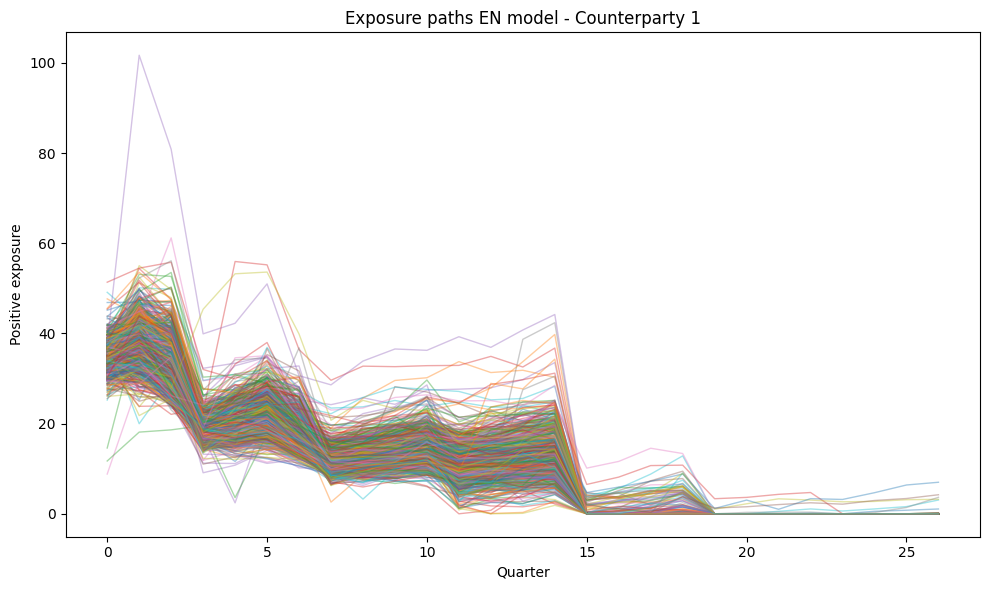

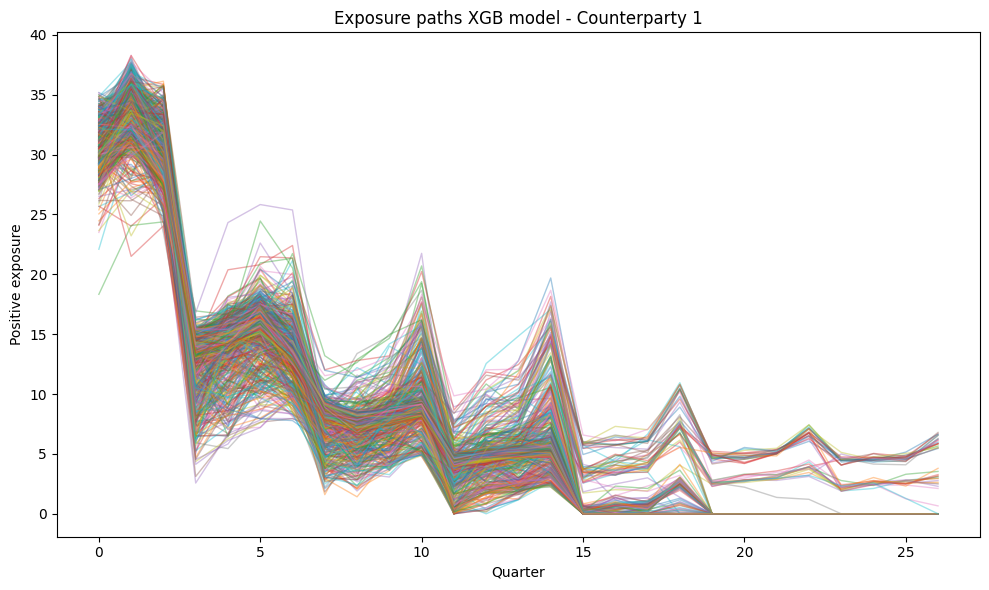

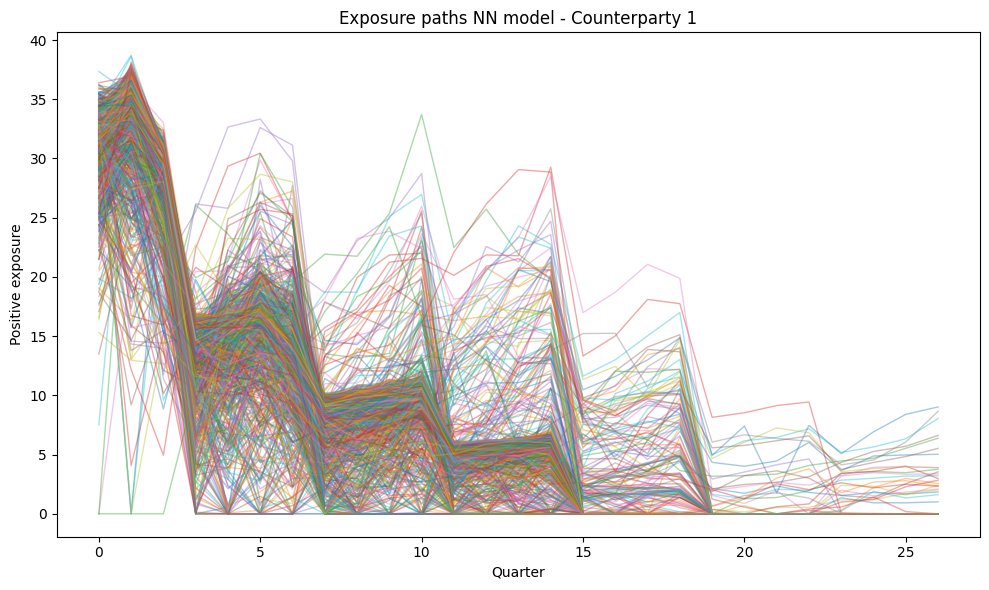

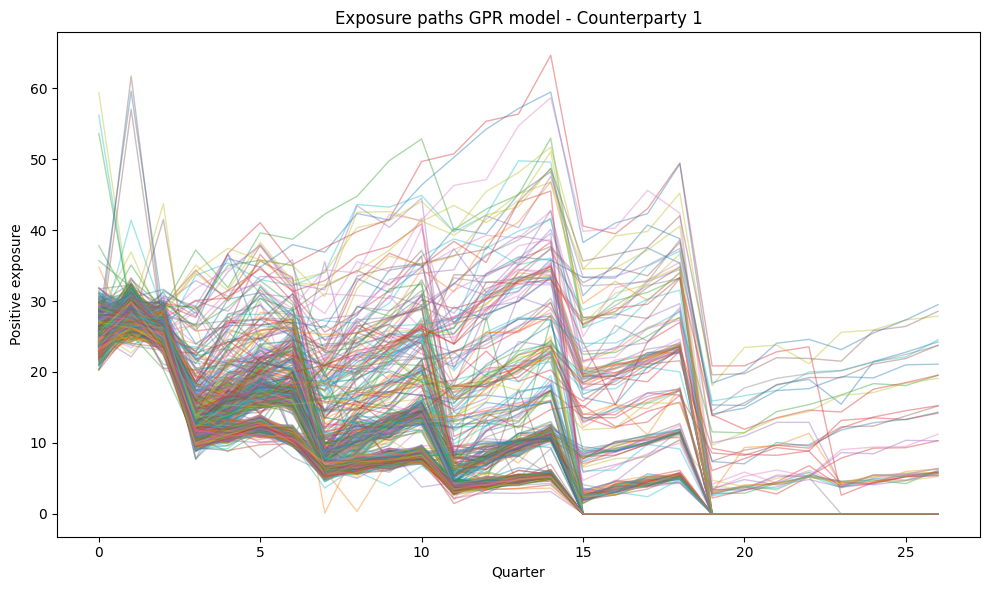

In [1]:
# Exposure plots
import pickle, glob, os
import numpy as np
import matplotlib.pyplot as plt

path = r"C:\Users\14gij\OneDrive\Documenten\1 Master\Thesis\thesis code\CVA\exposure_and_cva_files"

with open(os.path.join(path, f"exposures_final_en_2025-07-26.pkl"), "rb") as fh:
        exposures_en = pickle.load(fh)


with open(os.path.join(path, f"exposures_final_xgb_2025-07-26.pkl"), "rb") as fh:
        exposures_xgb = pickle.load(fh)

        
with open(os.path.join(path, f"exposures_final_nn_2025-07-26.pkl"), "rb") as fh:
        exposures_nn = pickle.load(fh)


with open(os.path.join(path, f"exposures_final_gpr_2025-07-26.pkl"), "rb") as fh:
        exposures_gpr = pickle.load(fh)



cp_idx = 0                     # 0 = first counterparty (DANSKE in your script)
n_steps = exposures_en[0].shape[0]      # number of price points / timesteps
t = np.arange(n_steps)                  # simple x-axis; replace by PRICE_POINTS/252 for years if you like

plt.figure(figsize=(10, 6))
for exp in exposures_en:                # one exp per simulation
    plt.plot(t, exp[:, cp_idx], alpha=0.4, lw=1)

plt.title(f"Exposure paths EN model - Counterparty {cp_idx + 1}")
plt.xlabel("Quarter")
plt.ylabel("Positive exposure")
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
for exp in exposures_xgb:                # one exp per simulation
    plt.plot(t, exp[:, cp_idx], alpha=0.4, lw=1)

plt.title(f"Exposure paths XGB model - Counterparty {cp_idx + 1}")
plt.xlabel("Quarter")
plt.ylabel("Positive exposure")
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
for exp in exposures_nn:                # one exp per simulation
    plt.plot(t, exp[:, cp_idx], alpha=0.4, lw=1)

plt.title(f"Exposure paths NN model - Counterparty {cp_idx + 1}")
plt.xlabel("Quarter")
plt.ylabel("Positive exposure")
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
for exp in exposures_gpr:                # one exp per simulation
    plt.plot(t, exp[:, cp_idx], alpha=0.4, lw=1)

plt.title(f"Exposure paths GPR model - Counterparty {cp_idx + 1}")
plt.xlabel("Quarter")
plt.ylabel("Positive exposure")
plt.tight_layout()
plt.show()


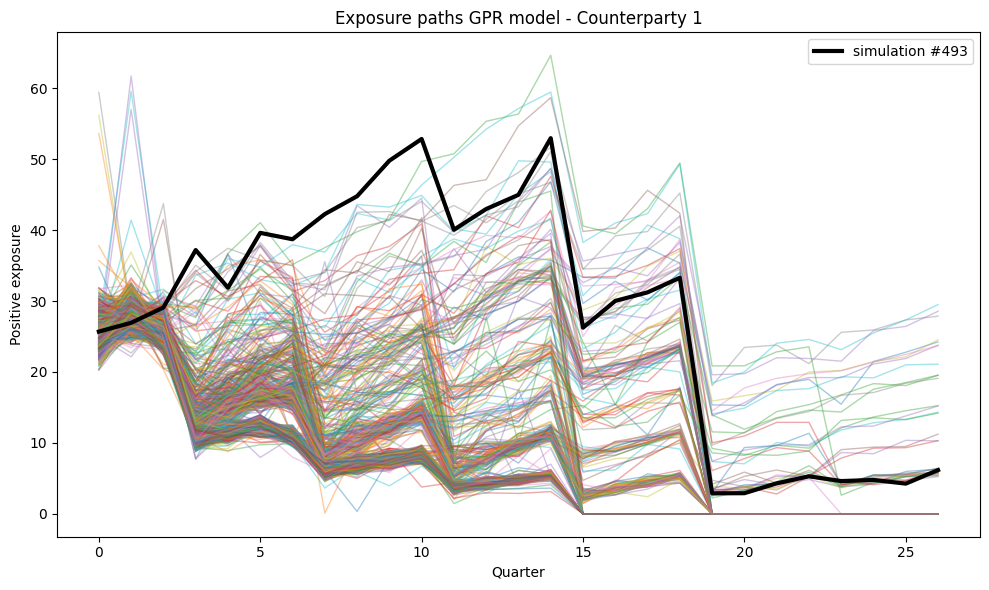

In [96]:
import pickle, os
import numpy as np
import matplotlib.pyplot as plt

path = r"C:\Users\UGGROO\OneDrive - Van Lanschot Kempen\Documents\MSc Thesis\3. Repos\thesis code\CVA\exposure_and_cva_files"

with open(os.path.join(path, "exposures_final_gpr_2025-07-26.pkl"), "rb") as fh:
    exposures_en = pickle.load(fh)

# ------------------------------------------------------------------
# Parameters
# ------------------------------------------------------------------
cp_idx   = 0       # counter-party column
path_idx = 492     # 759-th simulation (Python indexing starts at 0)
alpha_bg = 0.40    # transparency for the cloud of paths

# ------------------------------------------------------------------
# Build common x-axis
# ------------------------------------------------------------------
n_steps = exposures_en[0].shape[0]
t       = np.arange(n_steps)

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------
plt.figure(figsize=(10, 6))

# 1) Cloud of ALL paths (default colour cycle)
for i, exp in enumerate(exposures_en):
    if i == path_idx:                       # skip the one we want to highlight
        continue
    plt.plot(t, exp[:, cp_idx], lw=1, alpha=alpha_bg)

# 2) Highlighted 759-th path
plt.plot(t,
         exposures_en[path_idx][:, cp_idx],
         lw=3, color='black', label=f"simulation #{path_idx + 1}")

# ------------------------------------------------------------------
# Cosmetics
# ------------------------------------------------------------------
plt.title(f"Exposure paths GPR model - Counterparty {cp_idx + 1}")
plt.xlabel("Quarter")
plt.ylabel("Positive exposure")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

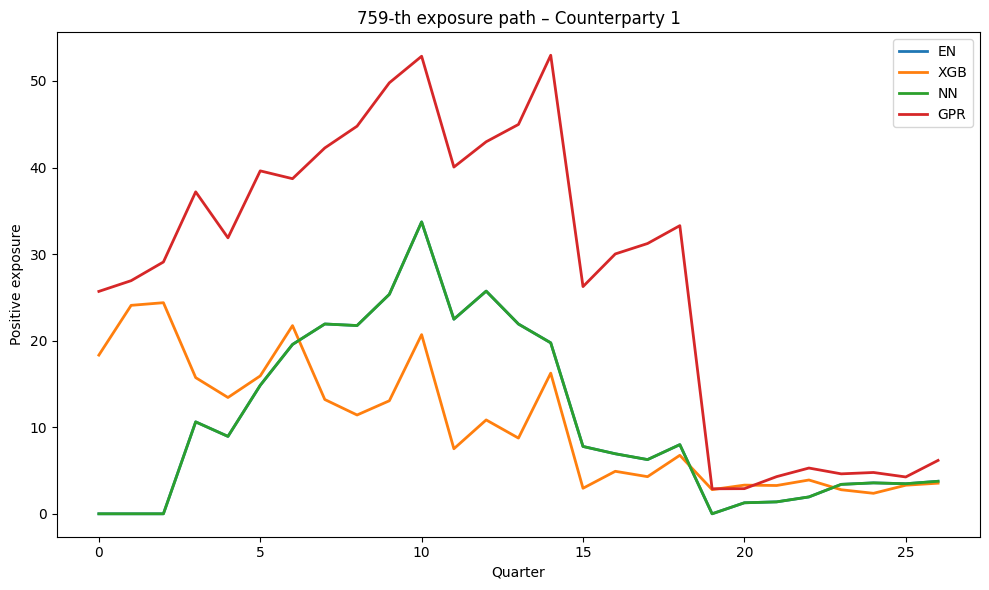

In [77]:
# ---------------------------------------------------------------
# Single-path comparison plot
#   – show the 758-th simulation path (index 757)  
#     for each of the four models on one figure
# ---------------------------------------------------------------

path_idx = 492         # 758-th path in 0-based indexing
cp_idx   = 0            # same counter-party as before

# sanity-check: make sure every list actually contains that path
for name, exp_list in [
        ('EN',  exposures_en),
        ('XGB', exposures_xgb),
        ('NN',  exposures_nn),
        ('GPR', exposures_gpr)]:
    if path_idx >= len(exp_list):
        raise IndexError(f"{name} only has {len(exp_list)} simulations; "
                         f"cannot access index {path_idx}")

# x-axis (same as in your first plot)
n_steps = exposures_en[0].shape[0]
t       = np.arange(n_steps)

plt.figure(figsize=(10, 6))

plt.plot(t, exposures_en [path_idx][:, cp_idx], label='EN' , lw=2)
plt.plot(t, exposures_xgb[path_idx][:, cp_idx], label='XGB', lw=2)
plt.plot(t, exposures_nn [path_idx][:, cp_idx], label='NN' , lw=2)
plt.plot(t, exposures_gpr[path_idx][:, cp_idx], label='GPR', lw=2)

plt.title(f"759-th exposure path – Counterparty {cp_idx + 1}")
plt.xlabel("Quarter")
plt.ylabel("Positive exposure")
plt.legend()
plt.tight_layout()
plt.show()

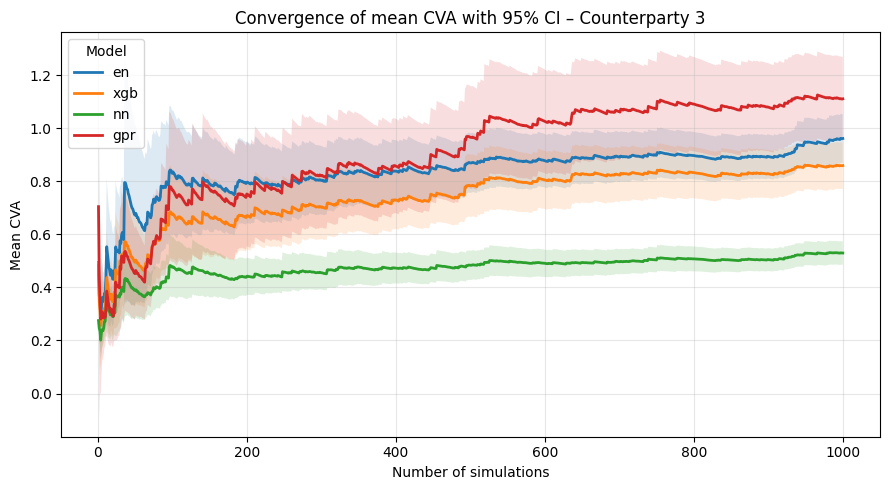

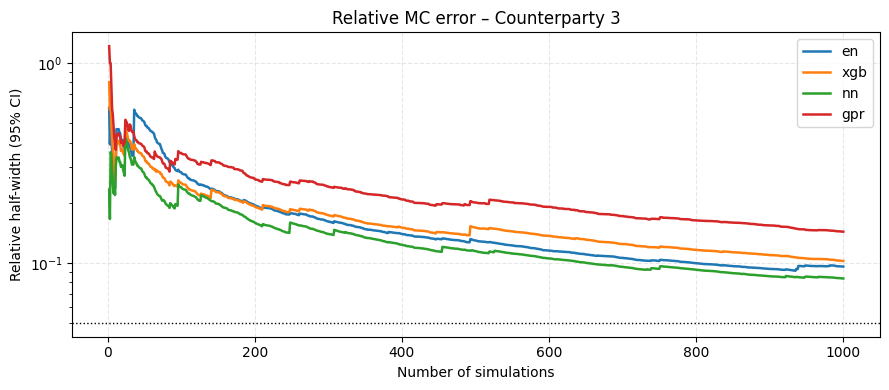


Convergence summary (Counterparty 3):
          n  mean_cva   se_mean  95%_halfwidth  rel_halfwidth n* (RSE<=1%)
model                                                                     
en     1000  0.961678  0.046953       0.092028       0.095696         None
xgb    1000  0.859474  0.044758       0.087726       0.102070         None
nn     1000  0.529864  0.022552       0.044202       0.083421         None
gpr    1000  1.111226  0.081099       0.158954       0.143044         None

=== Summary (mean, SE, 95% CI, etc.) ===
       EN                                                              \
        n      mean        sd        se        cv     ci_lo     ci_hi   
CP1  1000  7.530394  1.490442  0.047132  0.197923  7.437155  7.622324   
CP2  1000  7.586739  1.528326  0.048330  0.201447  7.494514  7.681822   
CP3  1000  7.499514  1.548747  0.048976  0.206513  7.405512  7.597156   

                            XGB  ...          NN   GPR                      \
         skew kurt_excess

In [102]:
# CVA convergence plots
with open(os.path.join(path, f"cva_final_2025-07-26.pkl"), "rb") as fh:
    cva = pickle.load(fh)


########## Single model code
# df_en   = cva["gpr"]                          
# cp_idx  = 1                               
# cp_name = df_en.columns[cp_idx]

# running_mean = df_en.iloc[:, cp_idx].expanding().mean()    

# plt.figure(figsize=(9, 5))
# plt.plot(np.arange(1, len(running_mean)+1), running_mean,
#          lw=2, label="Cumulative mean")
# plt.axhline(running_mean.iloc[-1], ls="--", linewidth=1,
#             label=f"Final mean = {running_mean.iloc[-1]:.2f}")

# plt.title(f"Convergence of mean CVA\nElastic-Net model – {cp_name}")
# plt.xlabel("Number of simulations")
# plt.ylabel("Mean CVA")
# plt.grid(True, alpha=0.3)
# plt.legend()
# plt.tight_layout()
# plt.show()


############ All model code
# cp_idx  = 1                              

# cumul_means = {}
# for model_name, df in cva.items():
#     col = df.columns[cp_idx]                 
#     cumul_means[model_name] = df[col].expanding().mean()  

# plt.figure(figsize=(9, 5))
# x = np.arange(1, len(next(iter(cumul_means.values()))) + 1)

# for model_name, series in cumul_means.items():
#     plt.plot(x, series, lw=2, label=model_name)

# final_vals = {m: s.iloc[-1] for m, s in cumul_means.items()}
# plt.title(f"Convergence of mean CVA – Counterparty {cp_idx + 1}")
# plt.xlabel("Number of simulations")
# plt.ylabel("Mean CVA")
# plt.grid(True, alpha=0.3)
# plt.legend(title="Model", loc="best")

# # optional: horizontal lines at final means
# for m, v in final_vals.items():
#     plt.axhline(v, ls="--", linewidth=0.8, alpha=0.5)

# plt.tight_layout()
# plt.show()



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cp_idx = 2       # your choice
Z = 1.96            # ~95% CI
TOL = 0.05         # 1% relative half-width target

def running_stats(x):
    """Return running mean, SE, 95% half-width, relative half-width, and the stopping n*."""
    x = np.asarray(x, float)
    n = np.arange(1, len(x) + 1)
    csum = np.cumsum(x)
    mean = csum / n
    csum2 = np.cumsum(x**2)
    var = np.empty_like(mean)
    var[:] = np.nan
    var[1:] = (csum2[1:] - n[1:] * mean[1:]**2) / (n[1:] - 1)   # unbiased sample variance
    se = np.sqrt(var / n)
    half = Z * se
    rse = half / np.abs(mean)
    # stopping rule: first n where rse <= TOL (after variance is defined)
    mask = ~np.isnan(rse) & (rse <= TOL)
    n_star = int(np.argmax(mask) + 1) if mask.any() else None
    return dict(n=n, mean=mean, se=se, half=half, rse=rse, n_star=n_star)

# ----------------------------------------------------------
# Compute running stats per model
# ----------------------------------------------------------
stats = {}
for model_name, df in cva.items():
    x = df.iloc[:, cp_idx].to_numpy()
    stats[model_name] = running_stats(x)

# ----------------------------------------------------------
# Plot 1: Convergence with 95% CI bands + stopping n*
# ----------------------------------------------------------
plt.figure(figsize=(9, 5))
for model_name, st in stats.items():
    n, mean, half = st['n'], st['mean'], st['half']
    plt.plot(n, mean, lw=2, label=model_name)
    plt.fill_between(n, mean - half, mean + half, alpha=0.15)
    if st['n_star'] is not None:
        plt.axvline(st['n_star'], ls='--', lw=0.8, alpha=0.6)

plt.title(f"Convergence of mean CVA with 95% CI – Counterparty {cp_idx + 1}")
plt.xlabel("Number of simulations")
plt.ylabel("Mean CVA")
plt.grid(True, alpha=0.3)
plt.legend(title="Model", loc="best")
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# Plot 2: Relative half-width (RSE) vs n (log-y)
# ----------------------------------------------------------
plt.figure(figsize=(9, 4))
for model_name, st in stats.items():
    n, rse = st['n'], st['rse']
    plt.plot(n, rse, label=model_name, lw=1.8)
    if st['n_star'] is not None:
        plt.axvline(st['n_star'], ls='--', lw=0.8, alpha=0.6)
plt.axhline(TOL, color='k', ls=':', lw=1)
plt.yscale('log')
plt.xlabel("Number of simulations")
plt.ylabel("Relative half-width (95% CI)")
plt.title(f"Relative MC error – Counterparty {cp_idx + 1}")
plt.grid(True, ls='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# Summary table
# ----------------------------------------------------------
summary_rows = []
for model_name, st in stats.items():
    n = st['n'][-1]
    mean = st['mean'][-1]
    se = st['se'][-1]
    half = st['half'][-1]
    rse = st['rse'][-1]
    n_star = st['n_star']
    summary_rows.append({
        "model": model_name,
        "n": n,
        "mean_cva": mean,
        "se_mean": se,
        "95%_halfwidth": half,
        "rel_halfwidth": rse,
        "n* (RSE<=1%)": n_star
    })

summary_df = pd.DataFrame(summary_rows).set_index("model")
print("\nConvergence summary (Counterparty {}):".format(cp_idx + 1))
print(summary_df.round(6))

import numpy as np
import pandas as pd
from itertools import combinations

# ============================================================
# Configuration
# ============================================================
N_BOOT = 5000      # bootstrap replications for CIs
ALPHAS  = [0.95, 0.975, 0.99]   # VaR/ES confidence levels
RANDOM_STATE = 42

# ============================================================
# Small utilities
# ============================================================
def _bootstrap_ci_mean(x, n_boot=N_BOOT, alpha=0.05, rng=None):
    """Percentile bootstrap CI for the mean."""
    if rng is None:
        rng = np.random.default_rng(RANDOM_STATE)
    x = np.asarray(x, float)
    n = len(x)
    boots = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.integers(0, n, n)
        boots[b] = np.mean(x[idx])
    lo, hi = np.quantile(boots, [alpha/2, 1 - alpha/2])
    return lo, hi

def _skew_kurt_excess(x):
    """Return (skewness, excess kurtosis) without SciPy."""
    x = np.asarray(x, float)
    n = len(x)
    mean = x.mean()
    s = x.std(ddof=1)
    if s == 0 or n < 3:
        return np.nan, np.nan
    m3 = np.mean((x - mean)**3)
    m4 = np.mean((x - mean)**4)
    skew = m3 / s**3
    kurt_excess = m4 / s**4 - 3.0
    return skew, kurt_excess

def _var_es(x, alpha):
    """Upper-tail VaR/ES for a positive CVA variable."""
    x = np.asarray(x, float)
    var = np.quantile(x, alpha)
    es = x[x >= var].mean()  # conditional mean above VaR
    return var, es

# ============================================================
# Core: compute all metrics for one vector (one model & cp)
# ============================================================
def _stats_for_series(x, alphas=ALPHAS, n_boot=N_BOOT, rng=None):
    x = np.asarray(x, float)
    n = len(x)
    mean = x.mean()
    sd = x.std(ddof=1)
    se = sd / np.sqrt(n)
    cv = sd / mean if mean != 0 else np.nan
    skew, kurt = _skew_kurt_excess(x)

    # Bootstrap CI on the mean
    lo, hi = _bootstrap_ci_mean(x, n_boot=n_boot, alpha=0.05, rng=rng)

    # Quantiles, VaR/ES
    q25, q50, q75 = np.quantile(x, [0.25, 0.5, 0.75])
    var_es = {}
    for a in alphas:
        var, es = _var_es(x, a)
        var_es[f"VaR_{int(a*100)}"] = var
        var_es[f"ES_{int(a*100)}"]  = es

    return {
        "n": n,
        "mean": mean,
        "sd": sd,
        "se": se,
        "cv": cv,
        "ci_lo": lo,
        "ci_hi": hi,
        "q25": q25,
        "median": q50,
        "q75": q75,
        "skew": skew,
        "kurt_excess": kurt,
        **var_es
    }

# ============================================================
# Pairwise differences between models (means + bootstrap CI)
# ============================================================
def _pairwise_diffs_tables(cva, n_boot=N_BOOT, rng=None):
    """
    Returns a dict of DataFrames (one per counterparty) containing
    mean differences and bootstrap CIs between every model pair.
    """
    if rng is None:
        rng = np.random.default_rng(RANDOM_STATE)

    models = list(cva.keys())
    n_cp = cva[models[0]].shape[1]
    cp_names = list(cva[models[0]].columns)
    if any(df.shape[1] != n_cp for df in cva.values()):
        raise ValueError("All models must have the same number of counterparties/columns")

    out = {}

    for cp_idx, cp_name in enumerate(cp_names):
        rows = []
        for m1, m2 in combinations(models, 2):
            x = cva[m1].iloc[:, cp_idx].to_numpy()
            y = cva[m2].iloc[:, cp_idx].to_numpy()
            # paired differences (assumes same simulation index alignment)
            d = x - y
            mean_d = d.mean()
            lo, hi = _bootstrap_ci_mean(d, n_boot=n_boot, alpha=0.05, rng=rng)
            rows.append({
                "pair": f"{m1} - {m2}",
                "mean_diff": mean_d,
                "ci_lo": lo,
                "ci_hi": hi
            })
        out[cp_name] = pd.DataFrame(rows).set_index("pair")

    return out

# ============================================================
# Cross-model dispersion (how far apart are the models?)
# ============================================================
def _cross_model_dispersion(cva):
    """
    For each counterparty, compute max-min and % spread
    of the *mean* CVA across models.
    """
    models = list(cva.keys())
    cp_names = list(cva[models[0]].columns)
    rows = []
    for cp_idx, cp_name in enumerate(cp_names):
        means = {m: cva[m].iloc[:, cp_idx].mean() for m in models}
        mean_vals = np.array(list(means.values()))
        spread_abs = mean_vals.max() - mean_vals.min()
        spread_pct = spread_abs / mean_vals.mean() if mean_vals.mean() != 0 else np.nan
        rows.append({
            "counterparty": cp_name,
            "min_mean_cva": mean_vals.min(),
            "max_mean_cva": mean_vals.max(),
            "avg_mean_cva": mean_vals.mean(),
            "abs_spread": spread_abs,
            "pct_spread": spread_pct
        })
    return pd.DataFrame(rows).set_index("counterparty")

# ============================================================
# Public API
# ============================================================
def build_all_cva_tables(cva,
                         alphas=ALPHAS,
                         n_boot=N_BOOT,
                         random_state=RANDOM_STATE):
    """
    Parameters
    ----------
    cva : dict[str, pd.DataFrame]
        Keys = model names. Each DataFrame has shape (n_sims, n_cp).
    alphas : list[float]
        Confidence levels for VaR/ES.
    n_boot : int
        Bootstrap replications for the CI of the mean.
    random_state : int
        RNG seed.

    Returns
    -------
    dict[str, pd.DataFrame or dict]:
        {
          'summary': DataFrame (MultiIndex columns: model → metrics),
          'tails'  : DataFrame (MultiIndex columns: model → tail metrics),
          'quantiles': DataFrame (MultiIndex columns: model → q25/median/q75),
          'pairwise_diffs': {cp_name: DataFrame of mean diffs + CIs for each model pair},
          'dispersion': DataFrame summarising cross-model spreads of mean CVA,
          'raw_stats_long': long DataFrame (model, cp, metric, value) — handy for custom plots
        }
    """
    rng = np.random.default_rng(random_state)
    models = list(cva.keys())
    # Harmonise CP names
    first_df = cva[models[0]]
    if first_df.columns is None or any(str(col).startswith("Unnamed") for col in first_df.columns):
        cp_names = [f"CP{i+1}" for i in range(first_df.shape[1])]
        for m in models:
            cva[m].columns = cp_names
    else:
        cp_names = list(first_df.columns)

    # Compute per-model, per-CP stats
    per_model_summary = {}
    per_model_tails = {}
    per_model_quantiles = {}
    long_rows = []

    tail_cols = sum(([f"VaR_{int(a*100)}", f"ES_{int(a*100)}"] for a in alphas), [])
    summary_cols = ["n", "mean", "sd", "se", "cv", "ci_lo", "ci_hi", "skew", "kurt_excess"]
    quant_cols = ["q25", "median", "q75"]

    for m in models:
        df = cva[m]
        rows_sum, rows_tail, rows_quant = [], [], []
        for cp in cp_names:
            stats = _stats_for_series(df[cp].values, alphas=alphas, n_boot=n_boot, rng=rng)

            # fill tables
            rows_sum.append({col: stats[col] for col in summary_cols})
            rows_tail.append({col: stats[col] for col in tail_cols})
            rows_quant.append({col: stats[col] for col in quant_cols})

            # long format
            for k, v in stats.items():
                long_rows.append({"model": m, "counterparty": cp, "metric": k, "value": v})

        per_model_summary[m]   = pd.DataFrame(rows_sum, index=cp_names)
        per_model_tails[m]     = pd.DataFrame(rows_tail, index=cp_names)
        per_model_quantiles[m] = pd.DataFrame(rows_quant, index=cp_names)

    # Wide, MultiIndex-column tables
    summary_tbl   = pd.concat(per_model_summary,   axis=1)
    tails_tbl     = pd.concat(per_model_tails,     axis=1)
    quantiles_tbl = pd.concat(per_model_quantiles, axis=1)

    # Pairwise model differences (per CP)
    pairwise_tbls = _pairwise_diffs_tables(cva, n_boot=n_boot, rng=rng)

    # Cross-model dispersion
    dispersion_tbl = _cross_model_dispersion(cva)

    long_df = pd.DataFrame(long_rows)

    return {
        "summary": summary_tbl,
        "tails": tails_tbl,
        "quantiles": quantiles_tbl,
        "pairwise_diffs": pairwise_tbls,
        "dispersion": dispersion_tbl,
        "raw_stats_long": long_df
    }

# ============================================================
# -------------------- Example usage -------------------------
# ============================================================
if __name__ == "__main__":
    # Example mock-up (replace with your real cva dict)
    # Suppose you already have:
    #   cva["EN"], cva["XGB"], cva["NN"], cva["GPR"]
    # each as a DataFrame (n_sims x n_cp)

    # Fake data just to illustrate:
    n_sims, n_cp = 1000, 3
    rng = np.random.default_rng(123)
    cp_cols = [f"CP{i+1}" for i in range(n_cp)]

    cva = {
        "EN":  pd.DataFrame(rng.lognormal(mean=2.0, sigma=0.2, size=(n_sims, n_cp)), columns=cp_cols),
        "XGB": pd.DataFrame(rng.lognormal(mean=2.05, sigma=0.22, size=(n_sims, n_cp)), columns=cp_cols),
        "NN":  pd.DataFrame(rng.lognormal(mean=1.95, sigma=0.25, size=(n_sims, n_cp)), columns=cp_cols),
        "GPR": pd.DataFrame(rng.lognormal(mean=2.00, sigma=0.18, size=(n_sims, n_cp)), columns=cp_cols),
    }

    res = build_all_cva_tables(cva)

    print("\n=== Summary (mean, SE, 95% CI, etc.) ===")
    print(res["summary"].round(6))

    print("\n=== Tail metrics (VaR / ES) ===")
    print(res["tails"].round(6))

    print("\n=== Quantiles (q25 / median / q75) ===")
    print(res["quantiles"].round(6))

    print("\n=== Cross-model dispersion of mean CVA ===")
    print(res["dispersion"].round(6))

    print("\n=== Pairwise model differences (per CP) ===")
    for cp, df in res["pairwise_diffs"].items():
        print(f"\nCounterparty: {cp}")
        print(df.round(6))

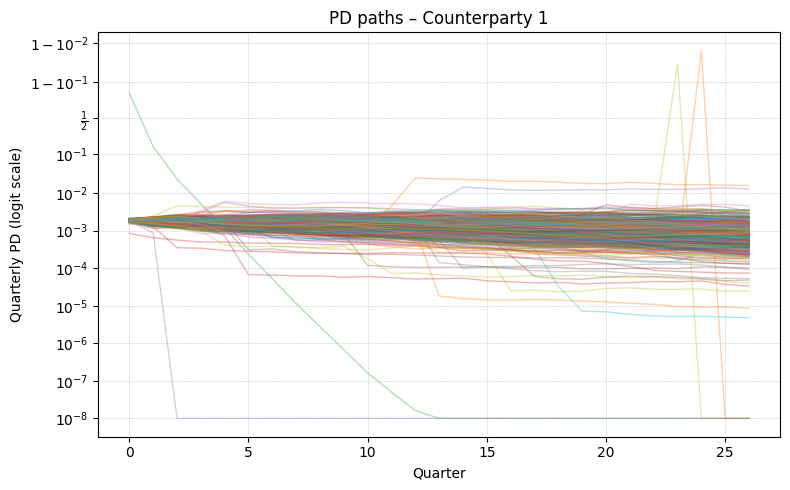

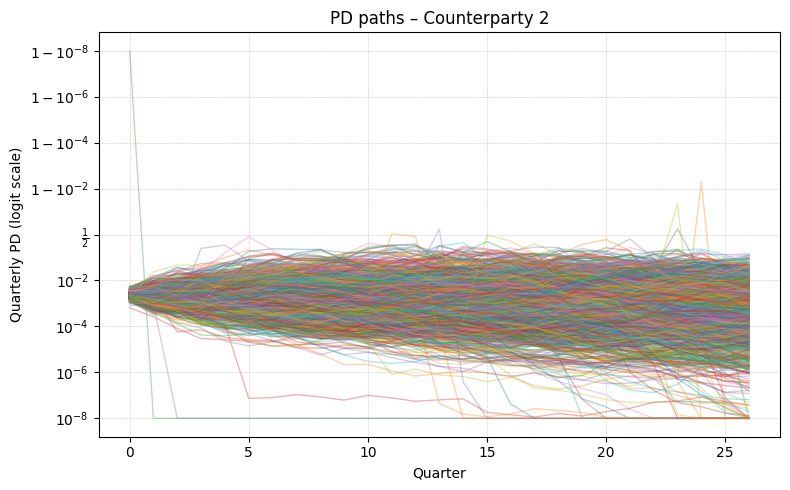

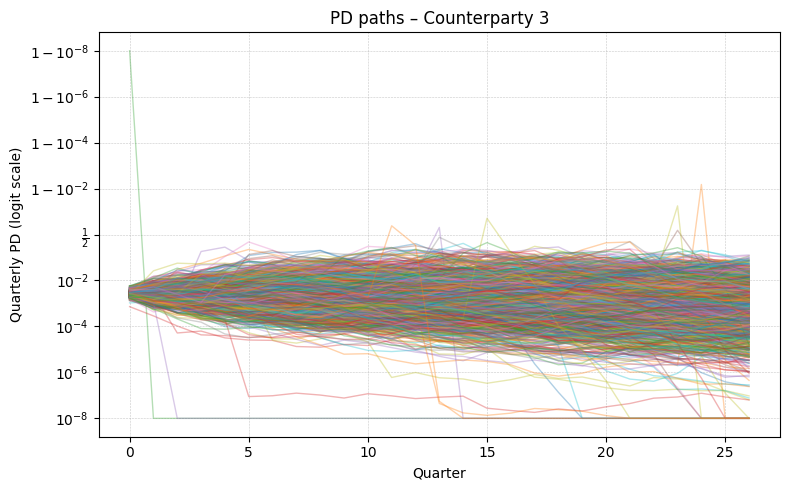

In [98]:

# # Correlation pd and exposure
# with open(os.path.join(path, f"pd_retuned_2025-07-23.pkl"), "rb") as fh:
#     pd_paths = pickle.load(fh)


# import matplotlib.pyplot as plt
# import numpy as np

# # --------------------------------------------------------------
# # dfs : list of 1 000 dataframes (each ≥ 3 columns)
# # --------------------------------------------------------------

# # ----------------------------------------------------------------
# # Make the x–axis identical to the one you already use for exposure
# # ----------------------------------------------------------------
# n_steps = pd_paths[0].shape[0]      # number of timesteps / price-points
# t       = np.arange(n_steps)   # x-values, identical to the exposure plot

# # If you have a custom tick set on the exposure plot, copy it:
# # exposure_ticks = plt.gca().get_xticks()   # only works if that axis still exists
# # exposure_ticklabels = plt.gca().get_xticklabels()

# titles = ['Counterparty 1', 'Counterparty 2', 'Counterparty 3']

# for col_idx in range(3):

#     plt.figure(figsize=(8, 5))

#     # Over-plot the same column from every dataframe
#     for df in pd_paths:
#         plt.plot(t, df.iloc[:, col_idx], alpha=0.35, lw=1)

#     # Cosmetics – identical x-axis labelling
#     plt.title(f"PD paths {titles[col_idx]}")
#     plt.xlabel("Quarter")           # <-- same label
#     plt.ylabel("Quarterly conditional PD")

#     # OPTIONAL: force the exact same tick positions / labels
#     # plt.xticks(exposure_ticks, exposure_ticklabels)

#     plt.tight_layout()

# plt.show()




# import matplotlib.pyplot as plt
# import numpy as np
# import pickle, os

# # --------------------------------------------------------------
# # Load PD simulations
# # --------------------------------------------------------------
# with open(os.path.join(path, "pd_retuned_2025-07-23.pkl"), "rb") as fh:
#     pd_paths = pickle.load(fh)

# # --------------------------------------------------------------
# # X-axis is the same as for the exposure plots
# # --------------------------------------------------------------
# n_steps = pd_paths[0].shape[0]
# t = np.arange(n_steps)

# titles = ['Counterparty 1', 'Counterparty 2', 'Counterparty 3']

# for col_idx in range(3):

#     fig, ax = plt.subplots(figsize=(8, 5))

#     # Plot every simulation path for the current counterparty
#     for df in pd_paths:
#         ax.plot(t, df.iloc[:, col_idx], alpha=0.35, lw=1)

#     # → LOG-SCALE on the y-axis
#     ax.set_yscale('log')

#     # Labels and cosmetics
#     ax.set_title(f"PD paths – {titles[col_idx]}")
#     ax.set_xlabel("Quarter")
#     ax.set_ylabel("Quarterly conditional PD (log scale)")
#     ax.grid(True, which='both', ls='--', lw=0.3, alpha=0.6)

#     plt.tight_layout()

# plt.show()


import pickle, os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker

# --------------------------------------------------------------
# Load PD simulations
# --------------------------------------------------------------
with open(os.path.join(path, "pd_final_2025-07-26.pkl"), "rb") as fh:
    pd_paths = pickle.load(fh)

# --------------------------------------------------------------
# Build common x-axis (same as exposure plots)
# --------------------------------------------------------------
n_steps = pd_paths[0].shape[0]
t = np.arange(n_steps)

titles = ['Counterparty 1', 'Counterparty 2', 'Counterparty 3']
eps = 1e-8                      # small number to avoid 0 or 1 exactly

for col_idx in range(3):

    fig, ax = plt.subplots(figsize=(8, 5))

    # Plot every simulation path for current counter-party
    for df in pd_paths:
        y = df.iloc[:, col_idx].clip(lower=eps, upper=1-eps)   # keep 0<p<1
        ax.plot(t, y, alpha=0.35, lw=1)

    # Use LOGIT scale on the y-axis
    ax.set_yscale('logit')

    # Optional: nice ticks for a logit axis
    ax.yaxis.set_major_locator(ticker.LogitLocator())
    ax.yaxis.set_minor_locator(ticker.NullLocator())

    # Cosmetics
    ax.set_title(f"PD paths – {titles[col_idx]}")
    ax.set_xlabel("Quarter")
    ax.set_ylabel("Quarterly PD (logit scale)")
    ax.grid(True, which='major', ls='--', lw=0.4, alpha=0.7)

    plt.tight_layout()

plt.show()




    
# cp_idx = 2                              # 0 = first counterparty (DANSKE in your script)
# n_steps = pd_paths[0].shape[0]      # number of price points / timesteps
# t = np.arange(n_steps)                  # simple x-axis; replace by PRICE_POINTS/252 for years if you like

# plt.figure(figsize=(10, 6))
# for pds in pd_paths:                # one exp per simulation
#     plt.plot(t, pds[:, cp_idx], alpha=0.5, lw=1)

# plt.title(f"Exposure paths – 'en' model, counterparty index {cp_idx}")
# plt.xlabel("Price-point index")
# plt.ylabel("Positive exposure")
# plt.tight_layout()
# plt.show()

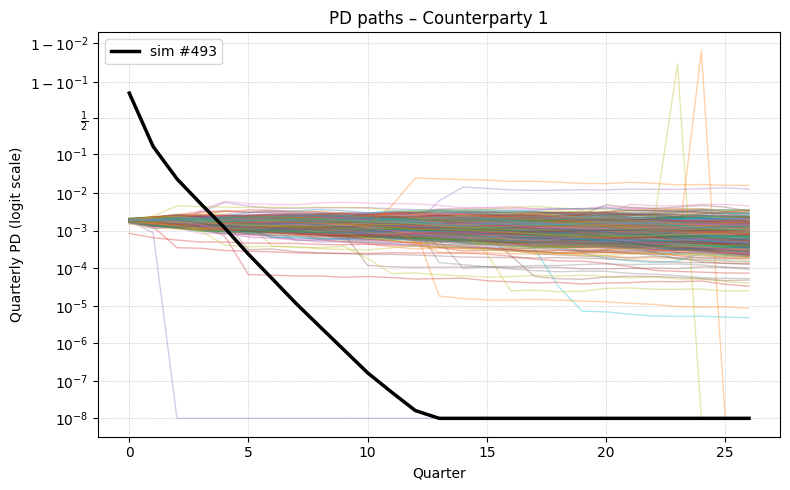

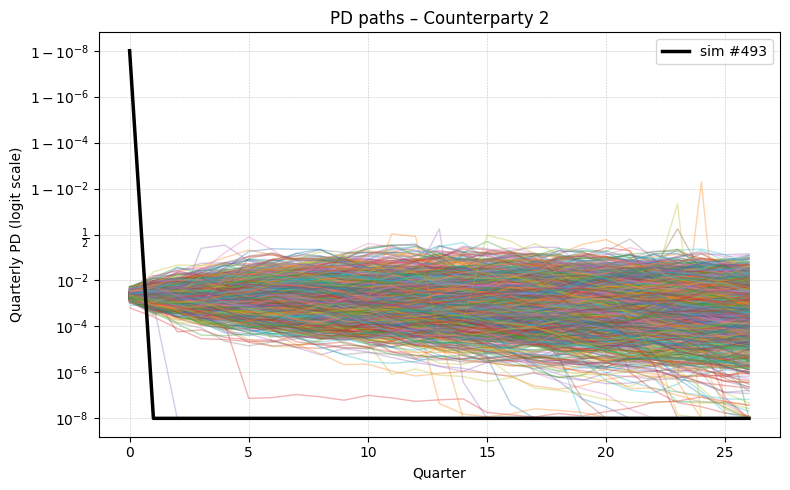

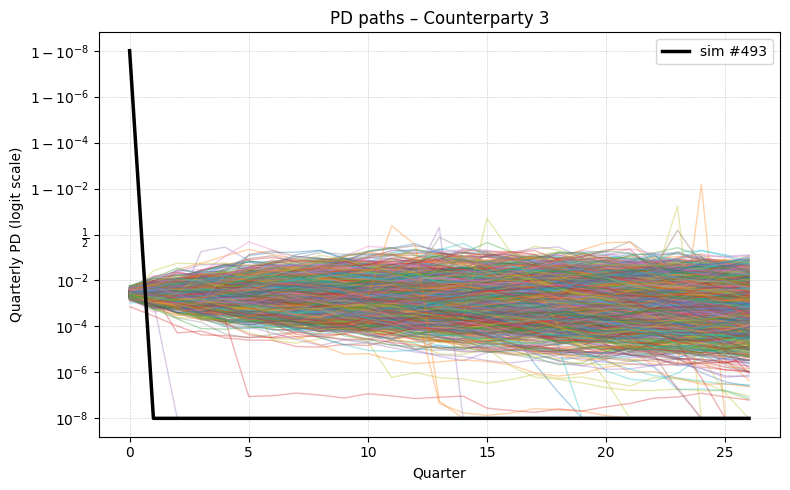

In [97]:
import os, pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker

# ------------------------------------------------------------------
# Parameters you may want to change
# ------------------------------------------------------------------
pkl_file      = os.path.join(path, "pd_final_2025-07-26.pkl")
scale         = "logit"      # "linear", "log", or "logit"
show_single   = True         # True = add the 759-th path as a thick line
single_idx    = 492          # (0-based) ⇒ 759-th simulation
single_cp     = 0            # 0, 1, or 2   (counterparty column)
alpha_cloud   = 0.35         # transparency of the cloud
eps           = 1e-8         # avoid exact 0 or 1 for log/logit

titles = ['Counterparty 1', 'Counterparty 2', 'Counterparty 3']


# ------------------------------------------------------------------
# Load PD simulations
# ------------------------------------------------------------------
with open(pkl_file, "rb") as fh:
    pd_paths = pickle.load(fh)          # list of dataframes

# ------------------------------------------------------------------
# Common x-axis
# ------------------------------------------------------------------
n_steps = pd_paths[0].shape[0]
t = np.arange(n_steps)


# ------------------------------------------------------------------
# Plot one figure per counterparty
# ------------------------------------------------------------------
for cp_idx in range(3):

    fig, ax = plt.subplots(figsize=(8, 5))

    # 1) Cloud of all paths
    for df in pd_paths:
        y = df.iloc[:, cp_idx].clip(lower=eps, upper=1-eps)
        ax.plot(t, y, lw=1, alpha=alpha_cloud)

    # 2) Optional: single highlighted path
    if show_single:
        single_y = pd_paths[single_idx].iloc[:, cp_idx].clip(lower=eps,
                                                             upper=1-eps)
        ax.plot(t, single_y, lw=2.5, color='black',
                label=f'sim #{single_idx+1}')

    # 3) Axis scaling
    if scale == "log":
        ax.set_yscale('log')
        ax.set_ylabel("Quarterly conditional PD (logit scale)")
    elif scale == "logit":
        ax.set_yscale('logit')
        ax.yaxis.set_major_locator(ticker.LogitLocator())
        ax.yaxis.set_minor_locator(ticker.NullLocator())
        ax.set_ylabel("Quarterly PD (logit scale)")
    else:                                   # linear
        ax.set_ylabel("Quarterly conditional PD")

    # Cosmetics
    ax.set_title(f"PD paths – {titles[cp_idx]}")
    ax.set_xlabel("Quarter")
    ax.grid(True, which='major', ls='--', lw=0.4, alpha=0.7)
    if show_single:
        ax.legend(loc='best')

    plt.tight_layout()

plt.show()

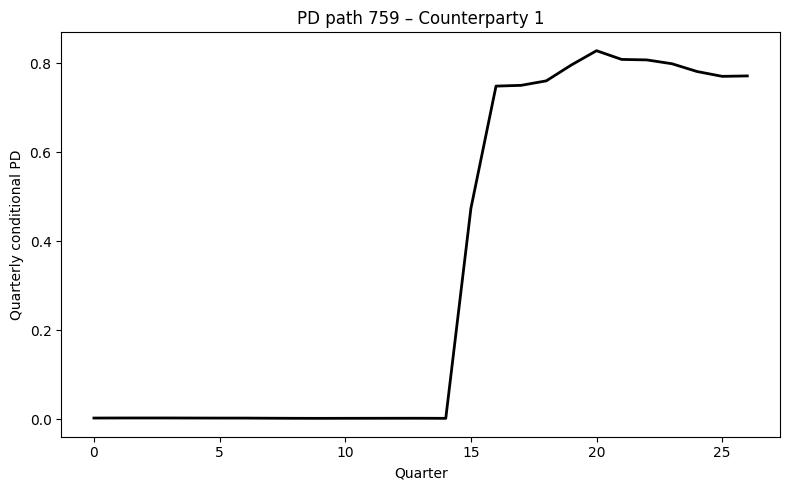

In [28]:
# --------------------------------------------------------------
# Single-path plot: 759-th PD path for counter-party 1
# --------------------------------------------------------------
path_idx = 758   # 0-based index → 759-th simulation
cp_idx   = 0     # 0 = counter-party 1

# Safety check (optional)
if path_idx >= len(pd_paths):
    raise IndexError(f"pd_paths has only {len(pd_paths)} simulations.")

plt.figure(figsize=(8, 5))
plt.plot(t, pd_paths[path_idx].iloc[:, cp_idx], lw=2, color='black')

plt.title(f"PD path {path_idx + 1} – Counterparty {cp_idx + 1}")
plt.xlabel("Quarter")
plt.ylabel("Quarterly conditional PD")
plt.tight_layout()
plt.show()